In [1]:
import pandas as pd

df = pd.read_csv("complex_health_dataset.csv")
df.head(5)

,Age,Gender,Smoker,BloodType,ExerciseLevel,BMI,BP_Systolic,BP_Diastolic,Cholesterol,Disease
0,76.0,Male,Yes,A,Low,24.0,NaN,106.0,267.0,NaN
1,36.0,Female,Yes,O,NaN,33.5,170.0,74.0,274.0,1.0
2,58.0,Male,Yes,O,High,23.9,173.0,65.0,173.0,0.0
3,41.0,Male,No,B,High,24.5,162.0,103.0,195.0,0.0
4,45.0,Male,No,AB,Medium,29.1,127.0,79.0,168.0,0.0


In [2]:
print("Rows, Columns: ", df.shape)

Rows, Columns:  (320, 10)


In [3]:
print("Missing values: \n", df.isnull().sum())

Missing values: 
 Age              15
Gender           17
Smoker           15
BloodType        15
ExerciseLevel    16
BMI              15
BP_Systolic      16
BP_Diastolic     17
Cholesterol      15
Disease          17
dtype: int64


In [4]:
print("Duplicates: ", df.duplicated().sum())

Duplicates:  20


In [5]:
df = df.drop_duplicates()

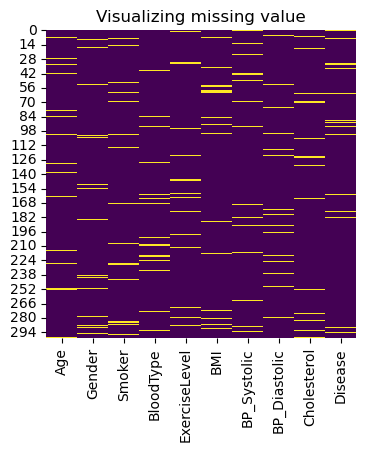

In [6]:
# Checking missing values
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Visualizing missing value")
plt.show()

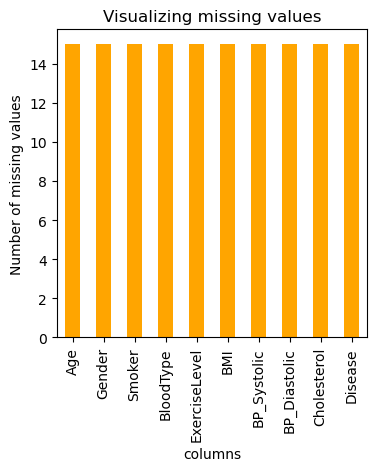

In [7]:
valueCounts = df.isnull().sum()

plt.figure(figsize=(4,4))
valueCounts.plot(kind='bar', color='orange')
plt.xlabel("columns")
plt.ylabel("Number of missing values")
plt.title("Visualizing missing values")
plt.show()

In [ ]:
categorical_cols = ['Gender', 'Smoker', 'BloodType', 'ExerciseLevel']
numerical_cols = [cols for cols in df.columns if cols not in categorical_cols + ['Disease']]

In [9]:
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())

In [10]:
categorical_cols

['Gender', 'Smoker', 'BloodType', 'ExerciseLevel']

In [11]:
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [12]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [14]:
df.columns

Index(['Age', 'BMI', 'BP_Systolic', 'BP_Diastolic', 'Cholesterol', 'Disease',
       'Gender_Male', 'Smoker_Yes', 'BloodType_AB', 'BloodType_B',
       'BloodType_O', 'ExerciseLevel_Low', 'ExerciseLevel_Medium'],
      dtype='object')

In [16]:
from sklearn.model_selection import train_test_split

x = df.drop('Disease', axis=1)
y = df['Disease']

y = y.fillna(y.mode()[0])

x_train, x_test, y_train, y_test = train_test_split(
    x, y, train_size=0.8, test_size=0.2, random_state=42
)

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

c:\Users\ashia\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy:  0.8666666666666667

Classification Report
               precision    recall  f1-score   support

         0.0       0.92      0.92      0.92        52
         1.0       0.50      0.50      0.50         8

    accuracy                           0.87        60
   macro avg       0.71      0.71      0.71        60
weighted avg       0.87      0.87      0.87        60



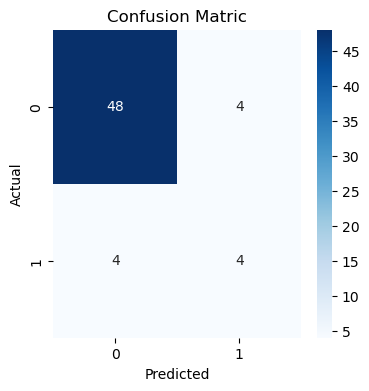

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('Accuracy: ', accuracy_score(y_test, y_pred))
print("\nClassification Report\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matric")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()